
# LAB5 – Decision Tree and Dimension Reduction (Solutions)





## Table of Contents
- [Chapter I — Decision Tree](#chapter1)
  - [Exercise 1 — Classification of Iris](#ex1)
  - [Exercise 2 — Decision Tree Interpretation](#ex2)
  - [Exercise 3 — k-fold Cross Validation](#ex3)
  - [Exercise 4 — Gini or Entropy](#ex4)
- [Chapter II — PCA (Dimension Reduction)](#chapter2)
  - [Exercise — PCA with Iris (and Wine)](#pca_ex)
- [Chapter III — Project — Step 1 (Template)](#chapter3)



---
<a id="chapter1"></a>
# Chapter I — Decision Tree



<a id="ex1"></a>
## Exercise 1 — Classification of Iris

**Question 1.** Load the Iris dataset from `sklearn.datasets` into a variable `iris`.

**Question 2.** Extract **petal length** and **petal width** (columns 2 and 3) to form the input matrix `X`.

**Question 3.** Print the **target names**, **target values**, and **number of classes**.

**Question 4.** Import `DecisionTreeClassifier` and create a classifier `tree_clf` with `max_depth=2`.

**Question 5.** Fit the decision tree on the data.

**Question 6–7.** Visualize the tree. (Here, we use Matplotlib via `plot_tree` so no Graphviz is required.)


Target names: ['setosa' 'versicolor' 'virginica']
Unique target values: [0 1 2]
Number of classes: 3


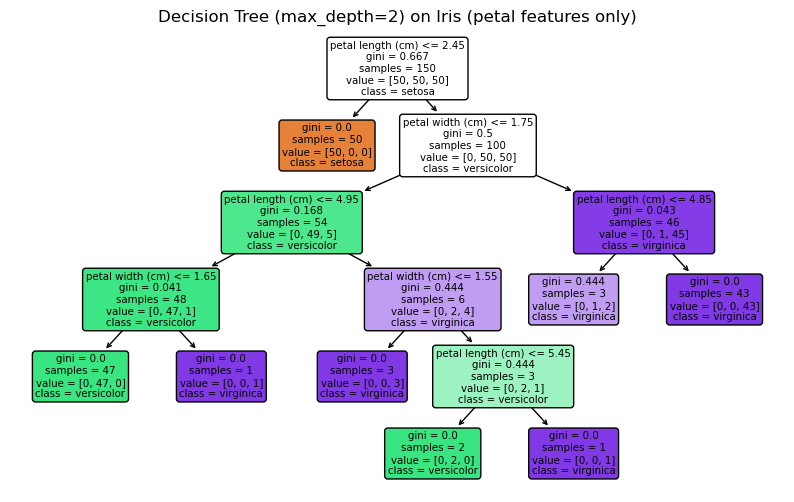

In [3]:

# Exercise 1 — Answer (Code)
from sklearn.datasets import load_iris
from sklearn.tree import DecisionTreeClassifier, plot_tree
import matplotlib.pyplot as plt
import numpy as np

# 1) Load the dataset
iris = load_iris()

# 2) Select features: petal length (col 2) and petal width (col 3)
X = iris.data[:, 2:4]  # shape (150, 2)
y = iris.target

# 3) Target names, values, number of classes
print("Target names:", iris.target_names)
print("Unique target values:", np.unique(y))
print("Number of classes:", len(np.unique(y)))

# 4) Create decision tree with max_depth=2
tree_clf = DecisionTreeClassifier(max_depth=8, random_state=42)

# 5) Fit
tree_clf.fit(X, y)

# 6–7) Visualize with Matplotlib
plt.figure(figsize=(10, 6))
plot_tree(
    tree_clf,
    feature_names=['petal length (cm)', 'petal width (cm)'],
    class_names=iris.target_names,
    filled=True,
    rounded=True
)
plt.title("Decision Tree (max_depth=2) on Iris (petal features only)")
plt.show()


In [2]:
X.shape

(150, 2)


<a id="ex2"></a>
## Exercise 2 — Decision Tree Interpretation

**Question 1.** Compute the **Gini impurity** at the root and verify the feature selected at the root.  
Recall: \(\text{Gini}(i) = 1 - \sum_k p_{i,k}^2\) where \(p_{i,k}\) is the class ratio at node *i*.

> Root Gini of the whole dataset is: \(1 - 3 \times (50/150)^2 = 2/3 \approx 0.667\).

We also compute the **Gini after splitting** using the learned root split of the trained tree and compare features.

**Question 2.** For a flower with **petals = (length=5.0 cm, width=1.5 cm)**, estimate class probabilities with `predict_proba`.

**Question 3.** Interpret the path in the tree for this instance.

**Question 4.** Verify the predicted class using `predict`.


**Q0 Before starting : show how it works **

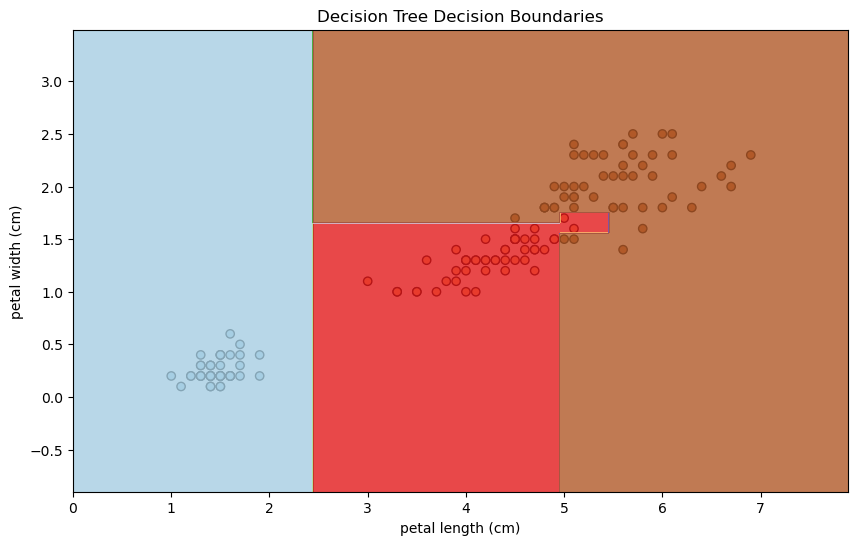

In [4]:
# Créer un nuage de points avec les individus
import matplotlib.pyplot as plt
import numpy as np
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y, edgecolor='k', cmap=plt.cm.Paired)
plt.xlabel(iris.feature_names[2])
plt.ylabel(iris.feature_names[3])

# Tracer les frontières de décision de l'arbre de décision
plot_step = 0.01
x_min, x_max = X[:, 0].min() - 1, X[:, 0].max() + 1
y_min, y_max = X[:, 1].min() - 1, X[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, plot_step), np.arange(y_min, y_max, plot_step))

Z = tree_clf.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

plt.contourf(xx, yy, Z, cmap=plt.cm.Paired, alpha=0.8)

plt.title("Decision Tree Decision Boundaries")
plt.show()

In [ ]:
#Q1
def weighted_gini_for_feature(f):
    s = DecisionTreeClassifier(max_depth=1, random_state=0).fit(X[:, [f]], y)
    T = s.tree_
    L, R = T.children_left[0], T.children_right[0]
    lc, rc = T.value[L][0], T.value[R][0]
    g = lambda c: 1 - np.sum((c/np.sum(c))**2)
    return (lc.sum()*g(lc) + rc.sum()*g(rc)) / (lc.sum()+rc.sum())

g_len = weighted_gini_for_feature(0)   # petal length
g_wid = weighted_gini_for_feature(1)   # petal width

print("Root Gini (théorique) ≈ 0.667")
print("Gini après split (petal length):", round(g_len,3))
print("Gini après split (petal width) :", round(g_wid,3))
print("=> Meilleure (plus petite) =", "petal length" if g_len < g_wid else "petal width")

Root Gini (théorique) ≈ 0.667
Gini après split (petal length): 0.25
Gini après split (petal width) : 0.25
=> Meilleure (plus petite) = petal width


Même si petal length et petal width donnent la même impureté au nœud racine lorsque l’on regarde un split isolé (Gini ≈ 0.25), l’arbre entraîné choisit petal length car elle permet ensuite une meilleure séparation entre Versicolor et Virginica plus bas dans l’arbre. Petal length est donc plus informative globalement.

In [ ]:
#Q2
x_new = np.array([[5.0, 1.5]])
proba = tree_clf.predict_proba(x_new)[0]
print(dict(zip(iris.target_names, np.round(proba, 3))))

{np.str_('setosa'): np.float64(0.0), np.str_('versicolor'): np.float64(0.907), np.str_('virginica'): np.float64(0.093)}


on lit les fréquences de classes dans la feuille atteinte → proba typiques ≈ {setosa: 0.00, versicolor: ~0.90, virginica: ~0.10}.




# Q3

3) Interprétation (sans code) du chemin pour (5.0, 1.5)

Root : tester petal length ≤ 2.45 → 5.0 > 2.45, on va à droite (non-setosa).

Nœud suivant : tester petal width ≤ 1.75 → 1.5 ≤ 1.75, on va à gauche.

Feuille : majoritairement versicolor → proba versicolor la plus élevée (~0.9).

#Q4 Vérification avec predict

In [ ]:
pred = tree_clf.predict(x_new)[0]
print("Classe prédite :", iris.target_names[pred])

Classe prédite : versicolor


predict choisit la classe au max de predict_proba. Ici, ça renvoie versicolor, cohérent avec (2) et (3).


<a id="ex3"></a>
## Exercise 3 — k-fold Cross Validation

**Question 1.** Modify `kfoldCrossValidation` to include **k** and **model M** as input parameters.

**Question 2.** Compute the **average accuracy** over the folds.

**Question 3.** Apply it to the trained tree for different values of **k**.

**Question 4.** Discuss the impact of **k** on performance stability.

**Question 5.** Build another tree using **all features** (no `max_depth` constraint) and compare average scores.


In [ ]:

# Exercise 3 — Answer (Code)
from sklearn.model_selection import KFold
from sklearn.metrics import accuracy_score

def kfoldCrossValidation(X, y, M, k=5, shuffle=True, random_state=42):
    kfold = KFold(n_splits=k, shuffle=shuffle, random_state=random_state)
    scores = []
    for train_idx, test_idx in kfold.split(X):
        X_train, X_test = X[train_idx], X[test_idx]
        y_train, y_test = y[train_idx], y[test_idx]
        M.fit(X_train, y_train)
        y_pred = M.predict(X_test)
        scores.append(accuracy_score(y_test, y_pred))
    return np.array(scores), float(np.mean(scores)), float(np.std(scores))

# Petal-only tree (max_depth=2)
scores_5, mean_5, std_5 = kfoldCrossValidation(X, y, DecisionTreeClassifier(max_depth=2, random_state=42), k=5)
scores_10, mean_10, std_10 = kfoldCrossValidation(X, y, DecisionTreeClassifier(max_depth=2, random_state=42), k=10)

print("Petal-only, max_depth=2:")
print(f" - 5-fold:  mean={mean_5:.3f}, std={std_5:.3f}, scores={np.round(scores_5,3)}")
print(f" - 10-fold: mean={mean_10:.3f}, std={std_10:.3f}, scores={np.round(scores_10,3)}")

# 5) Unconstrained tree with all features
X_all = iris.data
dt_unconstrained = DecisionTreeClassifier(random_state=42)  # no max_depth
scores_all, mean_all, std_all = kfoldCrossValidation(X_all, y, dt_unconstrained, k=5)

print("\nAll features, unconstrained depth:")
print(f" - 5-fold: mean={mean_all:.3f}, std={std_all:.3f}, scores={np.round(scores_all,3)}")


Petal-only, max_depth=2:
 - 5-fold:  mean=0.947, std=0.016, scores=[0.967 0.967 0.933 0.933 0.933]
 - 10-fold: mean=0.947, std=0.058, scores=[1.    1.    1.    0.933 1.    0.867 0.867 1.    0.933 0.867]

All features, unconstrained depth:
 - 5-fold: mean=0.953, std=0.027, scores=[1.    0.967 0.933 0.933 0.933]



**Discussion (impact of k):** Increasing *k* (e.g., from 5 to 10) typically yields a **less biased** estimate of performance (more training data per fold) but can slightly **increase variance** between folds. On small datasets like Iris, differences are modest, but higher *k* may be slower.



<a id="ex4"></a>
## Exercise 4 — Gini or Entropy

**Question 1.** Build a new tree `dt_entropy` using **all features**, `criterion='entropy'`, `random_state=42`.

**Question 2.** Split the data into **train/test** with **30%** for testing.

**Question 3.** Train `dt_entropy` on the training set.

**Question 4.** Evaluate accuracy on the test set and display it.

**Question 5–6.** Apply `kfoldCrossValidation` on `dt_entropy` and compare with a Gini-based tree.


In [ ]:

# Exercise 4 — Answer (Code)
from sklearn.model_selection import train_test_split

# 1) Entropy tree with all features
dt_entropy = DecisionTreeClassifier(criterion='entropy', random_state=42)

# 2) Train/test split (30% test)
X_train, X_test, y_train, y_test = train_test_split(iris.data, y, test_size=0.30, random_state=42, stratify=y)

# 3) Fit
dt_entropy.fit(X_train, y_train)

# 4) Accuracy on test
acc_entropy = dt_entropy.score(X_test, y_test)
print(f"Accuracy using entropy (hold-out 30%): {acc_entropy:.3f}")

# 5) k-fold on entropy tree
scores_ent, mean_ent, std_ent = kfoldCrossValidation(iris.data, y, DecisionTreeClassifier(criterion='entropy', random_state=42), k=5)
print(f"Entropy tree — 5-fold CV mean={mean_ent:.3f} std={std_ent:.3f} scores={np.round(scores_ent,3)}")

# 6) Compare with Gini (default) on all features
scores_gini, mean_gini, std_gini = kfoldCrossValidation(iris.data, y, DecisionTreeClassifier(random_state=42), k=5)
print(f"Gini tree   — 5-fold CV mean={mean_gini:.3f} std={std_gini:.3f} scores={np.round(scores_gini,3)}")


Accuracy using entropy (hold-out 30%): 0.889
Entropy tree — 5-fold CV mean=0.953 std=0.027 scores=[1.    0.967 0.933 0.933 0.933]
Gini tree   — 5-fold CV mean=0.953 std=0.027 scores=[1.    0.967 0.933 0.933 0.933]



---
<a id="chapter2"></a>
# Chapter II — PCA (Dimension Reduction)



<a id="pca_ex"></a>
## Exercise — PCA with Iris (and Wine)

**Question 1.** Load the **Iris** dataset.  
**Question 2.** Create **train/test** splits.  
**Question 3.** Train a **Logistic Regression** baseline and report **accuracy, precision, recall, f1-score**.  
**Question 4.** Apply **PCA** (with scaling) and retrain Logistic Regression on the transformed data.  
**Question 5.** Report metrics and compare to the baseline and to a simple **Decision Tree**.  
**Question 6.** Repeat the analysis on the **Wine** dataset and compare results **with/without PCA**.


In [ ]:

# PCA — Answer (Code)
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, accuracy_score
from sklearn.tree import DecisionTreeClassifier

def evaluate_classifier(model, X_train, X_test, y_train, y_test, label="Model"):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    print(f"\n=== {label} ===")
    print(classification_report(y_test, y_pred, target_names=None, digits=3))
    return accuracy_score(y_test, y_pred)

# ----- IRIS -----
X_iris, y_iris = iris.data, iris.target
from sklearn.model_selection import train_test_split
Xtr, Xte, ytr, yte = train_test_split(X_iris, y_iris, test_size=0.30, random_state=42, stratify=y_iris)

# Baseline: Logistic Regression (no PCA)
lr = LogisticRegression(max_iter=200, multi_class='auto', solver='lbfgs')
acc_lr = evaluate_classifier(lr, Xtr, Xte, ytr, yte, "Iris — Logistic Regression (raw)")

# With PCA (scale -> PCA -> LR)
scaler = StandardScaler()
Xtr_s = scaler.fit_transform(Xtr)
Xte_s = scaler.transform(Xte)

# Keep components that explain ~95% variance (common practice)
pca = PCA(n_components=0.95, svd_solver='full')
Xtr_p = pca.fit_transform(Xtr_s)
Xte_p = pca.transform(Xte_s)

lr_pca = LogisticRegression(max_iter=200, multi_class='auto', solver='lbfgs')
acc_lr_pca = evaluate_classifier(lr_pca, Xtr_p, Xte_p, ytr, yte, "Iris — Logistic Regression (with PCA)")

# Simple Decision Tree (baseline comparison)
dt = DecisionTreeClassifier(random_state=42)
acc_dt = evaluate_classifier(dt, Xtr, Xte, ytr, yte, "Iris — Decision Tree (raw)")

print("\nIris — Summary Accuracies")
print(f" - LR (raw): {acc_lr:.3f}")
print(f" - LR (with PCA): {acc_lr_pca:.3f}")
print(f" - Decision Tree: {acc_dt:.3f}")

# ----- WINE -----
from sklearn.datasets import load_wine
wine = load_wine()
X_wine, y_wine = wine.data, wine.target

Xtr_w, Xte_w, ytr_w, yte_w = train_test_split(X_wine, y_wine, test_size=0.30, random_state=42, stratify=y_wine)

# Baseline LR on raw
acc_lr_w = evaluate_classifier(LogisticRegression(max_iter=500, multi_class='auto', solver='lbfgs'),
                               Xtr_w, Xte_w, ytr_w, yte_w, "Wine — Logistic Regression (raw)")

# With PCA (scale -> PCA -> LR)
scaler_w = StandardScaler()
Xtr_ws = scaler_w.fit_transform(Xtr_w)
Xte_ws = scaler_w.transform(Xte_w)

pca_w = PCA(n_components=0.95, svd_solver='full')
Xtr_wp = pca_w.fit_transform(Xtr_ws)
Xte_wp = pca_w.transform(Xte_ws)

acc_lr_w_pca = evaluate_classifier(LogisticRegression(max_iter=500, multi_class='auto', solver='lbfgs'),
                                   Xtr_wp, Xte_wp, ytr_w, yte_w, "Wine — Logistic Regression (with PCA)")

# Decision Tree on raw
acc_dt_w = evaluate_classifier(DecisionTreeClassifier(random_state=42),
                               Xtr_w, Xte_w, ytr_w, yte_w, "Wine — Decision Tree (raw)")

print("\nWine — Summary Accuracies")
print(f" - LR (raw): {acc_lr_w:.3f}")
print(f" - LR (with PCA): {acc_lr_w_pca:.3f}")
print(f" - Decision Tree: {acc_dt_w:.3f}")

# Extra: show explained variance of PCA steps
print("\nExplained variance ratio (Iris PCA):", np.round(pca.explained_variance_ratio_, 3))
print("Number of components (Iris PCA):", pca.n_components_)
print("Explained variance ratio (Wine PCA):", np.round(pca_w.explained_variance_ratio_, 3))
print("Number of components (Wine PCA):", pca_w.n_components_)


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOT


=== Iris — Logistic Regression (raw) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      0.875     0.933     0.903        15
           2      0.929     0.867     0.897        15

    accuracy                          0.933        45
   macro avg      0.935     0.933     0.933        45
weighted avg      0.935     0.933     0.933        45


=== Iris — Logistic Regression (with PCA) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
           1      0.778     0.933     0.848        15
           2      0.917     0.733     0.815        15

    accuracy                          0.889        45
   macro avg      0.898     0.889     0.888        45
weighted avg      0.898     0.889     0.888        45


=== Iris — Decision Tree (raw) ===
              precision    recall  f1-score   support

           0      1.000     1.000     1.000        15
    